# Analisi preliminare referti annotati reali

# Preliminari

In [253]:
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import json
import ast
from pprint import pprint

In [254]:
# set plot style
plt.style.use('ggplot')

# Load Data

In [255]:
# Get data

data_path = Path('../data/base.tumoreprimitivo.csv/')
# Se il file non è presente, inserirlo manualmente prendendolo dalla cartella dropbox

data = pd.read_csv(data_path)

In [256]:
print(f'{data.shape = }')
display(data.head(2))

data.shape = (229, 45)


,id,profile,discrepanze_rilevate,motivazioni_discrepanze,radiologist,patient_id,sesso,data_nascita,interpretazioni,report_text,...,coinvolgimento_fascia_mesorettale,distanza_minima_fascia_ore,linfonodi_sospetti,numero_linfonodi_non_conosciuto,sedi_locoregionali,sedi_non_locoregionali,depositi_tumorali,numero_depositi,emvi_esteso,status
0,306,GuidoImbemba,['nessuna'],nessuna,NaN,6167209,F,1951-01-16,NaN,IN CORRISPONDENZA DELLA PARETE LATERALE DESTRA...,...,NaN,NaN,3.0,False,['mesorettali'],[],NaN,0.0,no,complete
1,305,GuidoImbemba,['nessuna'],nessuna,NaN,32798134,M,1949-01-23,NaN,SI SEGNALA LA PRESENZA IN CORRISPONDENZA DEL R...,...,NaN,NaN,0.0,True,['rettali_superiori'],[],NaN,0.0,no,complete


# Elimina righe doppie

In [257]:
print(f'Shape iniziale: {data.shape}')

# Intere righe duplicate. Keep last perchè i report hanno id decrescente
duplicati = data.iloc[:, 1:].duplicated(keep='last')
print(f'Numero righe duplicate: {duplicati.sum()}')

data_clean = data[duplicati == False]
print('Righe doppie eliminate')

# Rimuovi righe con report duplicati
duplicati = data_clean['report_text'].duplicated(keep='last')
righe_report_duplicato = data_clean[duplicati]
print(f'Numero righe con stesso referto: {duplicati.sum()}')

data_clean = data_clean[duplicati == False]
print('Righe eliminate')

data_clean.reset_index(inplace=True, drop=True)

print(f'{data_clean.shape = }')

Shape iniziale: (229, 45)
Numero righe duplicate: 0
Righe doppie eliminate
Numero righe con stesso referto: 9
Righe eliminate
data_clean.shape = (220, 45)


In [258]:
# Sostituiamo valore -1 con 0 per la colonna numero depositi
data_clean.loc[data_clean['numero_depositi'] == -1.0, 'numero_depositi'] = 0.0

In [259]:
# Controllo coerenza dettagli organi extra
data_clean[(data_clean['infiltrazione_organi_dettagli'] > '') * (data_clean['infiltrazione_organi_extra'] == 'no')][['profile', 'infiltrazione_organi_dettagli', 'infiltrazione_organi_extra']]

,profile,infiltrazione_organi_dettagli,infiltrazione_organi_extra
31,GuidoImbemba,{'altro': 'vescichette seminali'},no
39,GuidoImbemba,{'sacro': True},no
42,GuidoImbemba,{'sacro': True},no
117,GuidoImbemba,{'pavimento_pelvico': True},no
143,PietroPaoloAzzaro,{'altro': 'infiltrazione della prostata da par...,no
144,PietroPaoloAzzaro,{'altro': 'infiltrazione della prostata da par...,no
145,PietroPaoloAzzaro,{'altro': 'infiltrazione della prostata da par...,no
148,PietroPaoloAzzaro,{'sacro': True},no
149,PietroPaoloAzzaro,{'sacro': True},no
150,PietroPaoloAzzaro,{'sacro': True},no


In [260]:
# Sostituiamo i valore con None nela colonna dei dettagli degli organi coinvolti pechè altri valori non sono compatibili con "no" nella colonna infiltrazione_organi_extra
for i in range(data_clean.shape[0]):
    if (data_clean.loc[i, 'infiltrazione_organi_extra'] == 'no') and (data_clean.loc[i, 'infiltrazione_organi_dettagli'] is not None):
        data_clean.loc[i, 'infiltrazione_organi_dettagli'] = None

display(data_clean[(data_clean['infiltrazione_organi_dettagli'] > '') * (data_clean['infiltrazione_organi_extra'] == 'no')][['profile', 'infiltrazione_organi_dettagli', 'infiltrazione_organi_extra']])

,profile,infiltrazione_organi_dettagli,infiltrazione_organi_extra


In [261]:
# creazione nuova colonna "sedi_linfonodi_sospetti"
sedi_linfonodi = []
for s1, s2 in zip(data_clean.sedi_locoregionali, data_clean.sedi_non_locoregionali):
    sedi_linfonodi.append(str(ast.literal_eval(s1) + ast.literal_eval(s2)))
data_clean['sedi_linfonodi'] = sedi_linfonodi
data_clean[['sedi_locoregionali', 'sedi_non_locoregionali', 'sedi_linfonodi']].head(10)

,sedi_locoregionali,sedi_non_locoregionali,sedi_linfonodi
0,['mesorettali'],[],['mesorettali']
1,['rettali_superiori'],[],['rettali_superiori']
2,"['mesorettali', 'rettali_superiori', 'otturato...",[],"['mesorettali', 'rettali_superiori', 'otturato..."
3,[],[],[]
4,"['mesorettali', 'rettali_superiori']",[],"['mesorettali', 'rettali_superiori']"
5,"['iliaci_interni', 'otturatori']",['inguinali'],"['iliaci_interni', 'otturatori', 'inguinali']"
6,"['mesorettali', 'rettali_superiori', 'otturato...",[],"['mesorettali', 'rettali_superiori', 'otturato..."
7,['mesorettali'],[],['mesorettali']
8,[],[],[]
9,[],[],[]


# Analisi preliminari delle colonne

In [262]:
print(data_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 46 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      220 non-null    int64  
 1   profile                                 220 non-null    object 
 2   discrepanze_rilevate                    220 non-null    object 
 3   motivazioni_discrepanze                 220 non-null    object 
 4   radiologist                             2 non-null      object 
 5   patient_id                              220 non-null    int64  
 6   sesso                                   218 non-null    object 
 7   data_nascita                            219 non-null    object 
 8   interpretazioni                         83 non-null     object 
 9   report_text                             220 non-null    object 
 10  morfologia                              212 non-null    object

In [263]:
# Fill NaN for plotting purposes
data_plot = data_clean.fillna('NaN')
data_ilaria = data_plot[data_plot['profile'] == 'IlariaNacci']
data_plot = data_plot.drop(index=data_plot[data_plot['profile'] == 'IlariaNacci'].index)

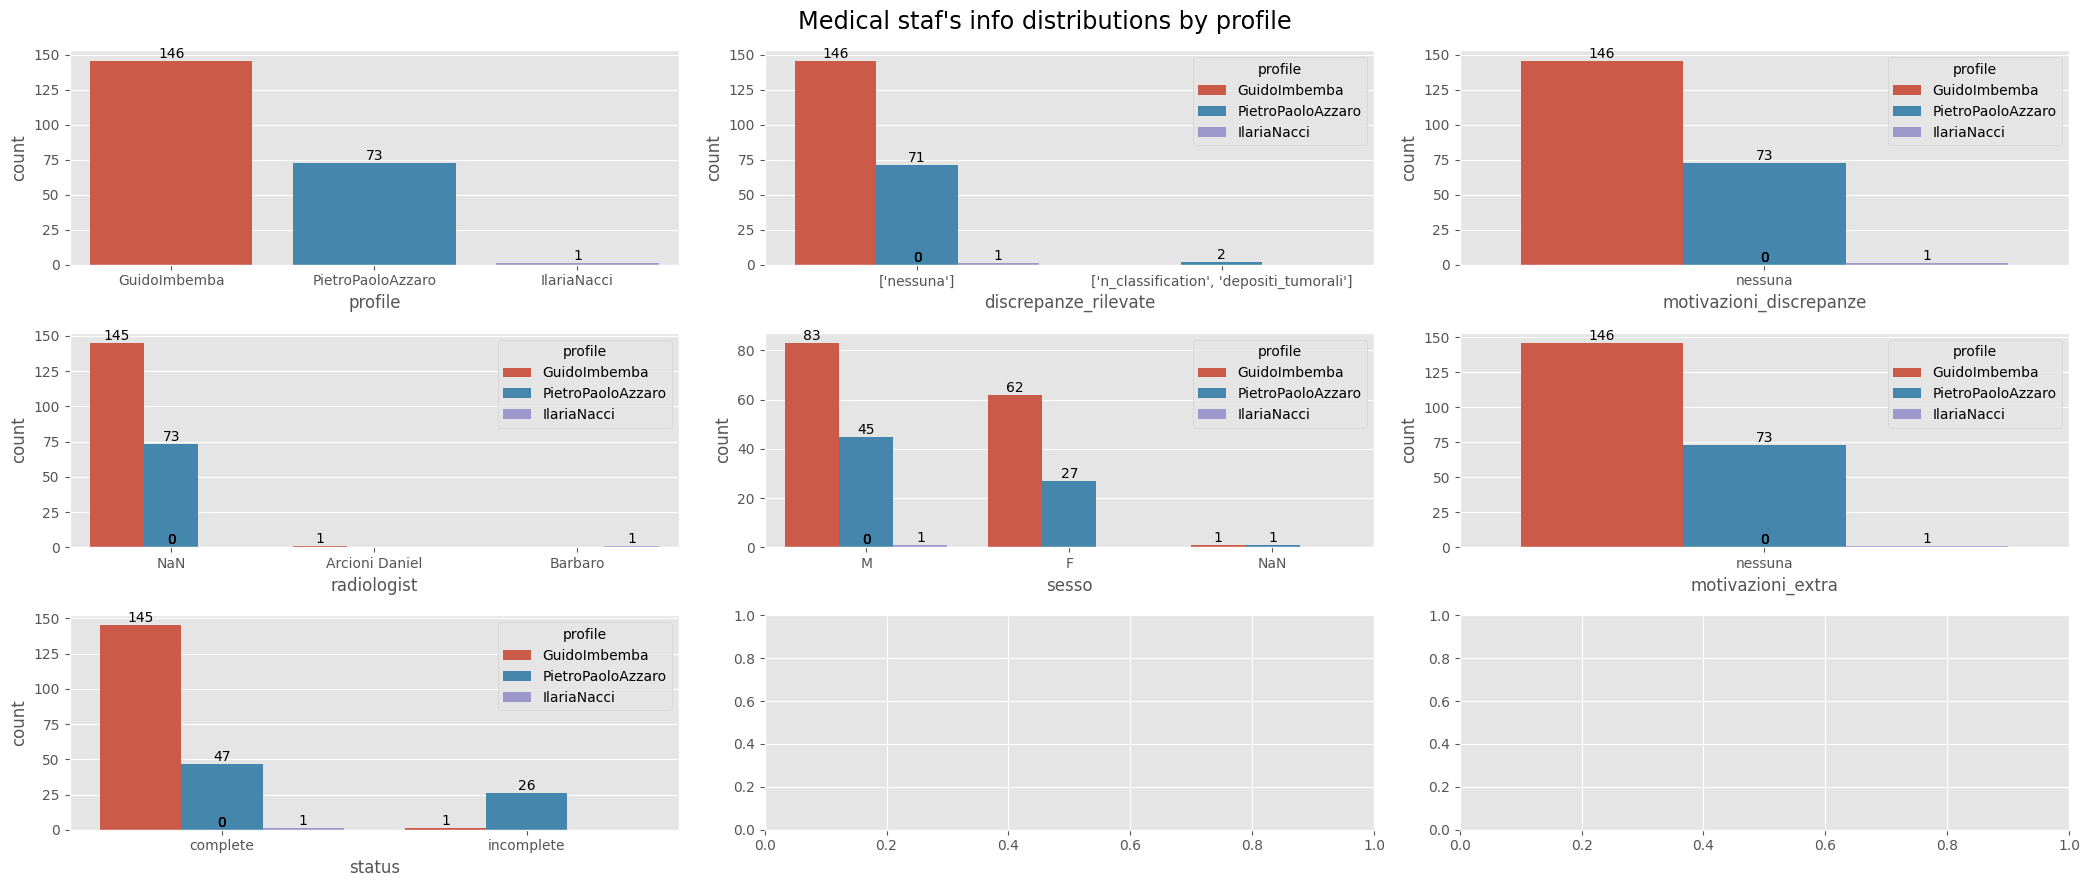

In [264]:
columns_plot = ['profile', 'discrepanze_rilevate', 'motivazioni_discrepanze', 'radiologist', 'sesso', 'motivazioni_extra', 'status']
#columns_plot = ['profile', 'status']
hue_column = 'profile'

data_x = pd.concat([data_plot, data_ilaria])
include_ilaria = True
print_statistics = False

n_columns = min(3, len(columns_plot))
n_rows, r = divmod(len(columns_plot), n_columns)
if r != 0:
    n_rows += 1

fig, axes = plt.subplots(n_rows, n_columns, figsize=(n_columns*7, n_rows*3))
fig.suptitle("Medical staf's info distributions by profile", fontsize='xx-large')

for i, col in enumerate(columns_plot):
    if n_rows == 1:
        ax = axes[i]
    else:
        ax=axes[i//n_columns][i%n_columns]
    if include_ilaria:
        sns.countplot(data=data_x, x=col, order=data_x[col].value_counts().index, ax=ax, hue=hue_column)
    else:
        sns.countplot(data=data_plot, x=col, order=data_plot[col].value_counts().index, ax=ax, hue=hue_column)
    # Add values on top of bars
    for p in ax.patches:
        y_text = int(p.get_height())
        x_text = p.get_x() + p.get_width() / 2
        ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')

plt.tight_layout()
#plt.savefig("distribuzione_status_per_annotatore.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()

if print_statistics:
    columns = ['profile', 'discrepanze_rilevate', 'motivazioni_discrepanze', 'radiologist', 'sesso', 'motivazioni_extra', 'status']
    print(f'{len(columns) = }\n')
    for col in columns:
        print(data_clean[col].value_counts().to_frame().T)
        print("\n")

Ilaria told us to exclude Pietro's records. We also see how there is only one status = incomplete records of Guido.  

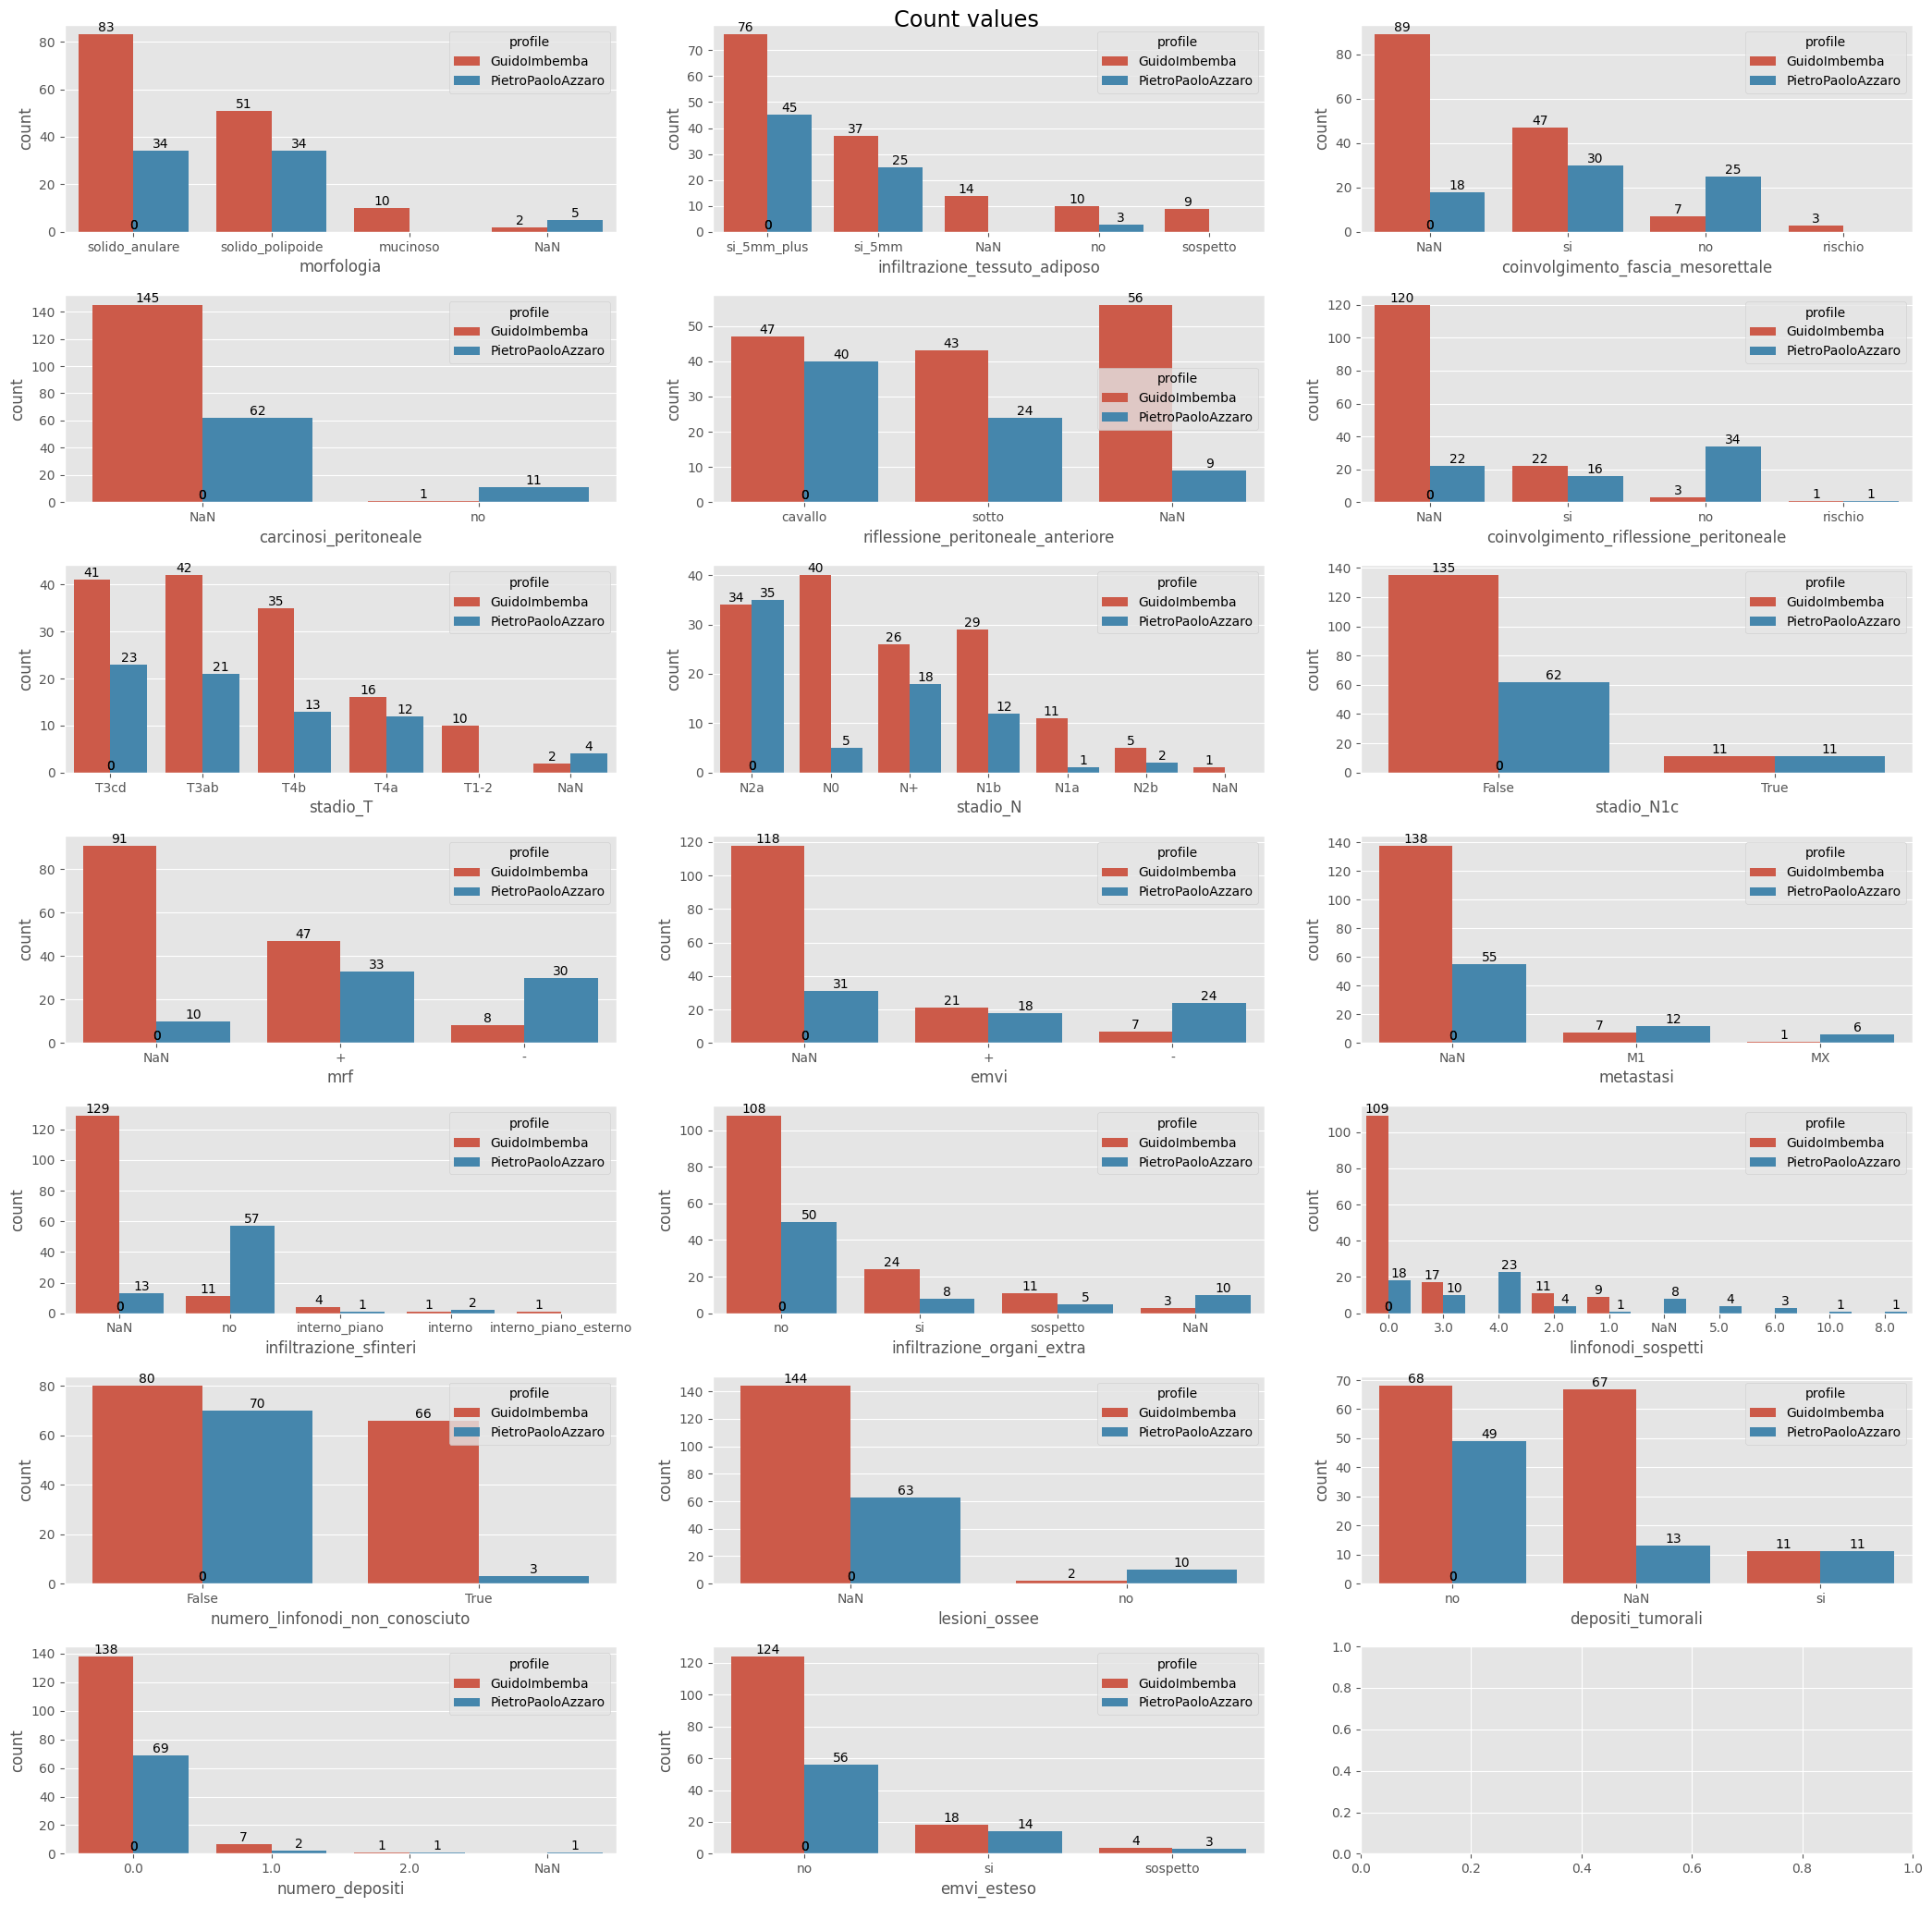

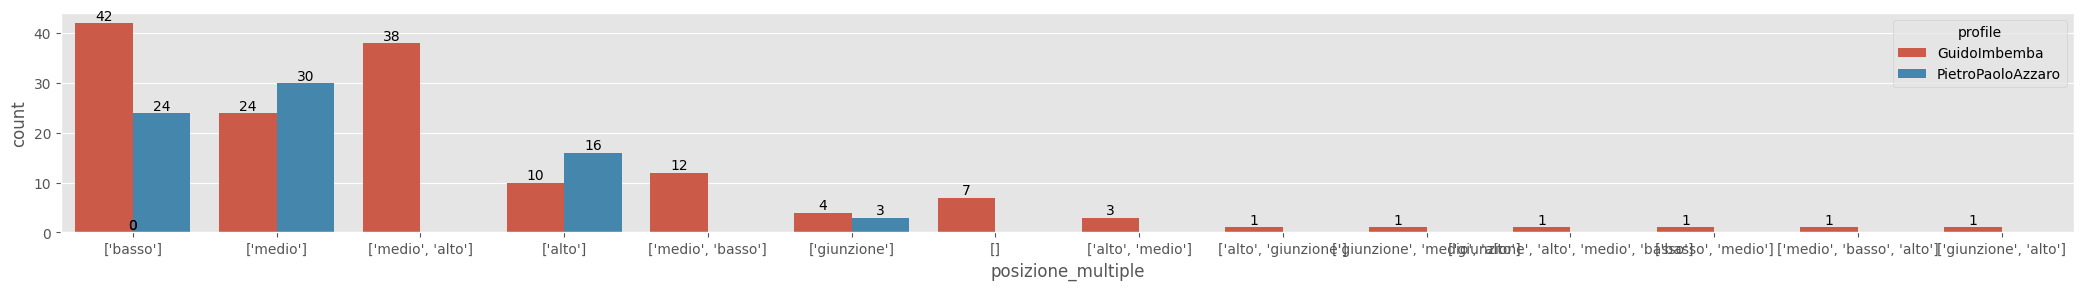

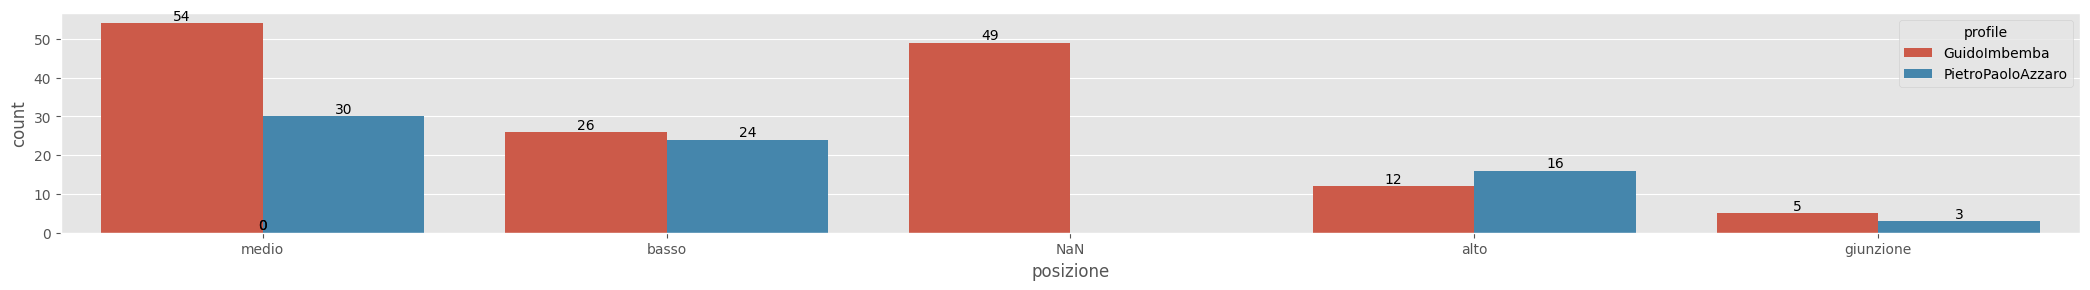

In [265]:
columns_plot = ['morfologia', 'infiltrazione_tessuto_adiposo', 'coinvolgimento_fascia_mesorettale',
                'carcinosi_peritoneale', 'riflessione_peritoneale_anteriore', 'coinvolgimento_riflessione_peritoneale',
                'stadio_T', 'stadio_N', 'stadio_N1c',
                'mrf', 'emvi', 'metastasi',
                'infiltrazione_sfinteri', 'infiltrazione_organi_extra',
                'linfonodi_sospetti', 'numero_linfonodi_non_conosciuto', 'lesioni_ossee',
                'depositi_tumorali', 'numero_depositi', 'emvi_esteso']

#hue_column = 'depositi_tumorali'
#columns_plot = [hue_column] + columns_plot

n_columns = 3
n_rows, r = divmod(len(columns_plot), n_columns)
if r != 0:
    n_rows += 1
    
fig, axes = plt.subplots(n_rows, n_columns, figsize=(n_columns*7, n_rows*3))
fig.suptitle("Count values", fontsize='xx-large')

for i, col in enumerate(columns_plot):
    ax=axes[i//n_columns][i%n_columns]
    sns.countplot(data=data_plot, x=col, order=data_plot[col].value_counts().index, ax=ax, hue=hue_column)
    # Add values on top of bars
    for p in ax.patches:
        y_text = int(p.get_height())
        x_text = p.get_x() + p.get_width() / 2
        ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')

plt.tight_layout()
#plt.savefig("distribuzione_featurse_per_annotatore.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()

fig, ax = plt.subplots(figsize=(21, 3))
sns.countplot(data=data_plot, x='posizione_multiple', order=data_plot['posizione_multiple'].value_counts().index, ax=ax, hue='profile')
# Add values on top of bars
for p in ax.patches:
    y_text = int(p.get_height())
    x_text = p.get_x() + p.get_width() / 2
    ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(21, 3))
sns.countplot(data=data_plot, x='posizione', order=data_plot['posizione'].value_counts().index, ax=ax, hue='profile')
# Add values on top of bars
for p in ax.patches:
    y_text = int(p.get_height())
    x_text = p.get_x() + p.get_width() / 2
    ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

**We see many anomalies between Guido and Pietro style of annortation. For this reason and also for what Ilaria told us, we will take into consideration only reports annotated by Guido**

# Guido's rows

In [267]:
data_clean_guido = data_clean[data_clean['profile'] == 'GuidoImbemba'].copy(deep=True)
data_clean_guido.reset_index(inplace=True, drop=True)
data_plot = data_clean_guido.fillna('NaN')

print(data_clean_guido.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 46 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      146 non-null    int64  
 1   profile                                 146 non-null    object 
 2   discrepanze_rilevate                    146 non-null    object 
 3   motivazioni_discrepanze                 146 non-null    object 
 4   radiologist                             1 non-null      object 
 5   patient_id                              146 non-null    int64  
 6   sesso                                   145 non-null    object 
 7   data_nascita                            146 non-null    object 
 8   interpretazioni                         64 non-null     object 
 9   report_text                             146 non-null    object 
 10  morfologia                              144 non-null    object

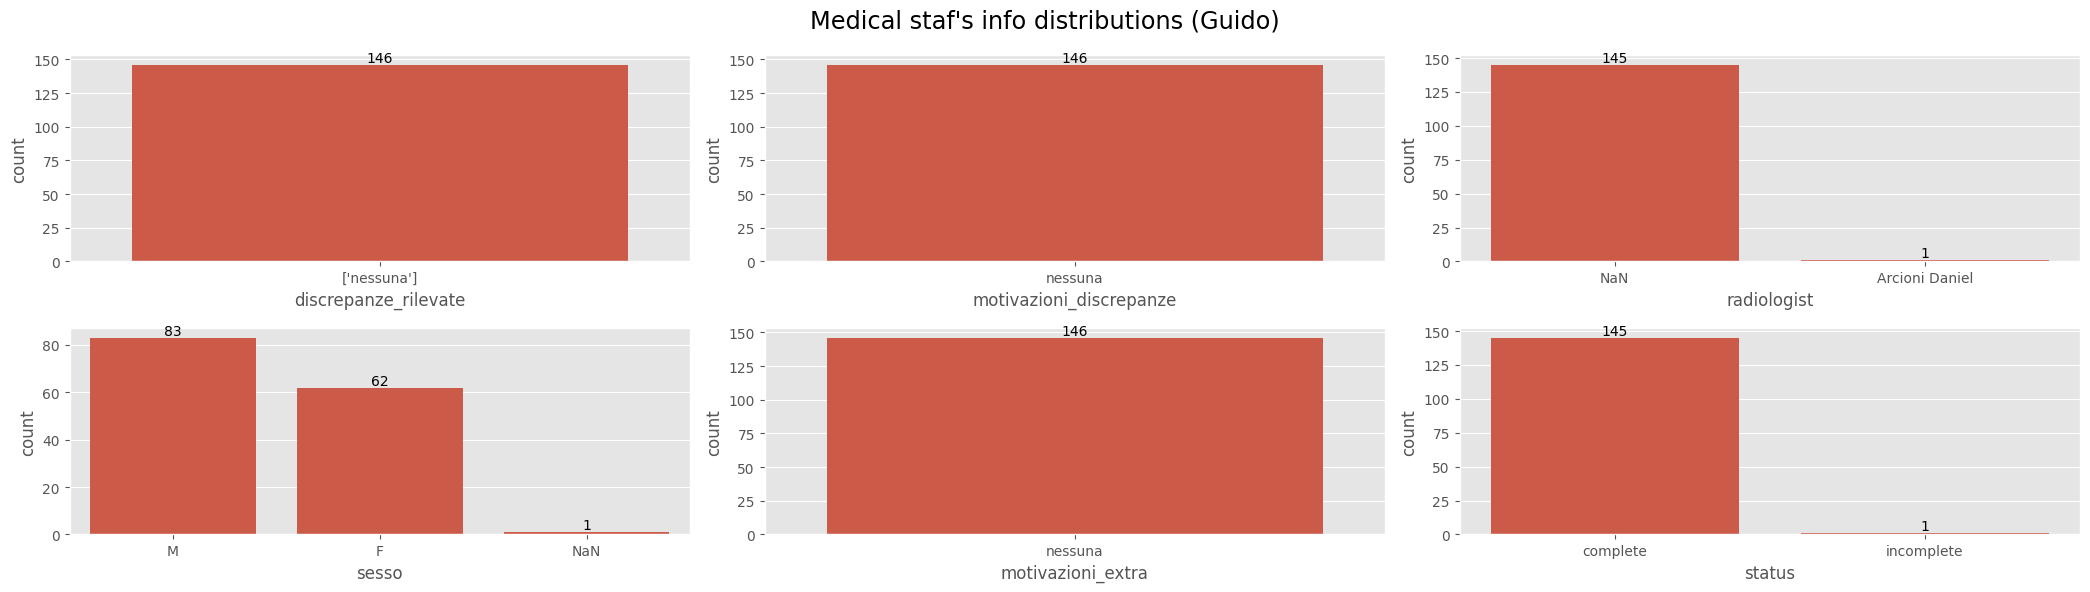

In [269]:
columns_plot = ['discrepanze_rilevate', 'motivazioni_discrepanze', 'radiologist', 'sesso', 'motivazioni_extra', 'status']

print_statistics = False

n_columns = min(3, len(columns_plot))
n_rows, r = divmod(len(columns_plot), n_columns)
if r != 0:
    n_rows += 1

fig, axes = plt.subplots(n_rows, n_columns, figsize=(n_columns*7, n_rows*3))
fig.suptitle("Medical staf's info distributions (Guido)", fontsize='xx-large')

for i, col in enumerate(columns_plot):
    if n_rows == 1:
        ax = axes[i]
    else:
        ax=axes[i//n_columns][i%n_columns]    
    sns.countplot(data=data_plot, x=col, order=data_plot[col].value_counts().index, ax=ax)
    # Add values on top of bars
    for p in ax.patches:
        y_text = int(p.get_height())
        x_text = p.get_x() + p.get_width() / 2
        ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')

plt.tight_layout()
#plt.savefig("distribuzione_status_per_annotatore.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()

if print_statistics:
    print(f'{len(columns_plot) = }\n')
    for col in columns_plot:
        print(data_plot[col].value_counts().to_frame().T)
        print("\n")

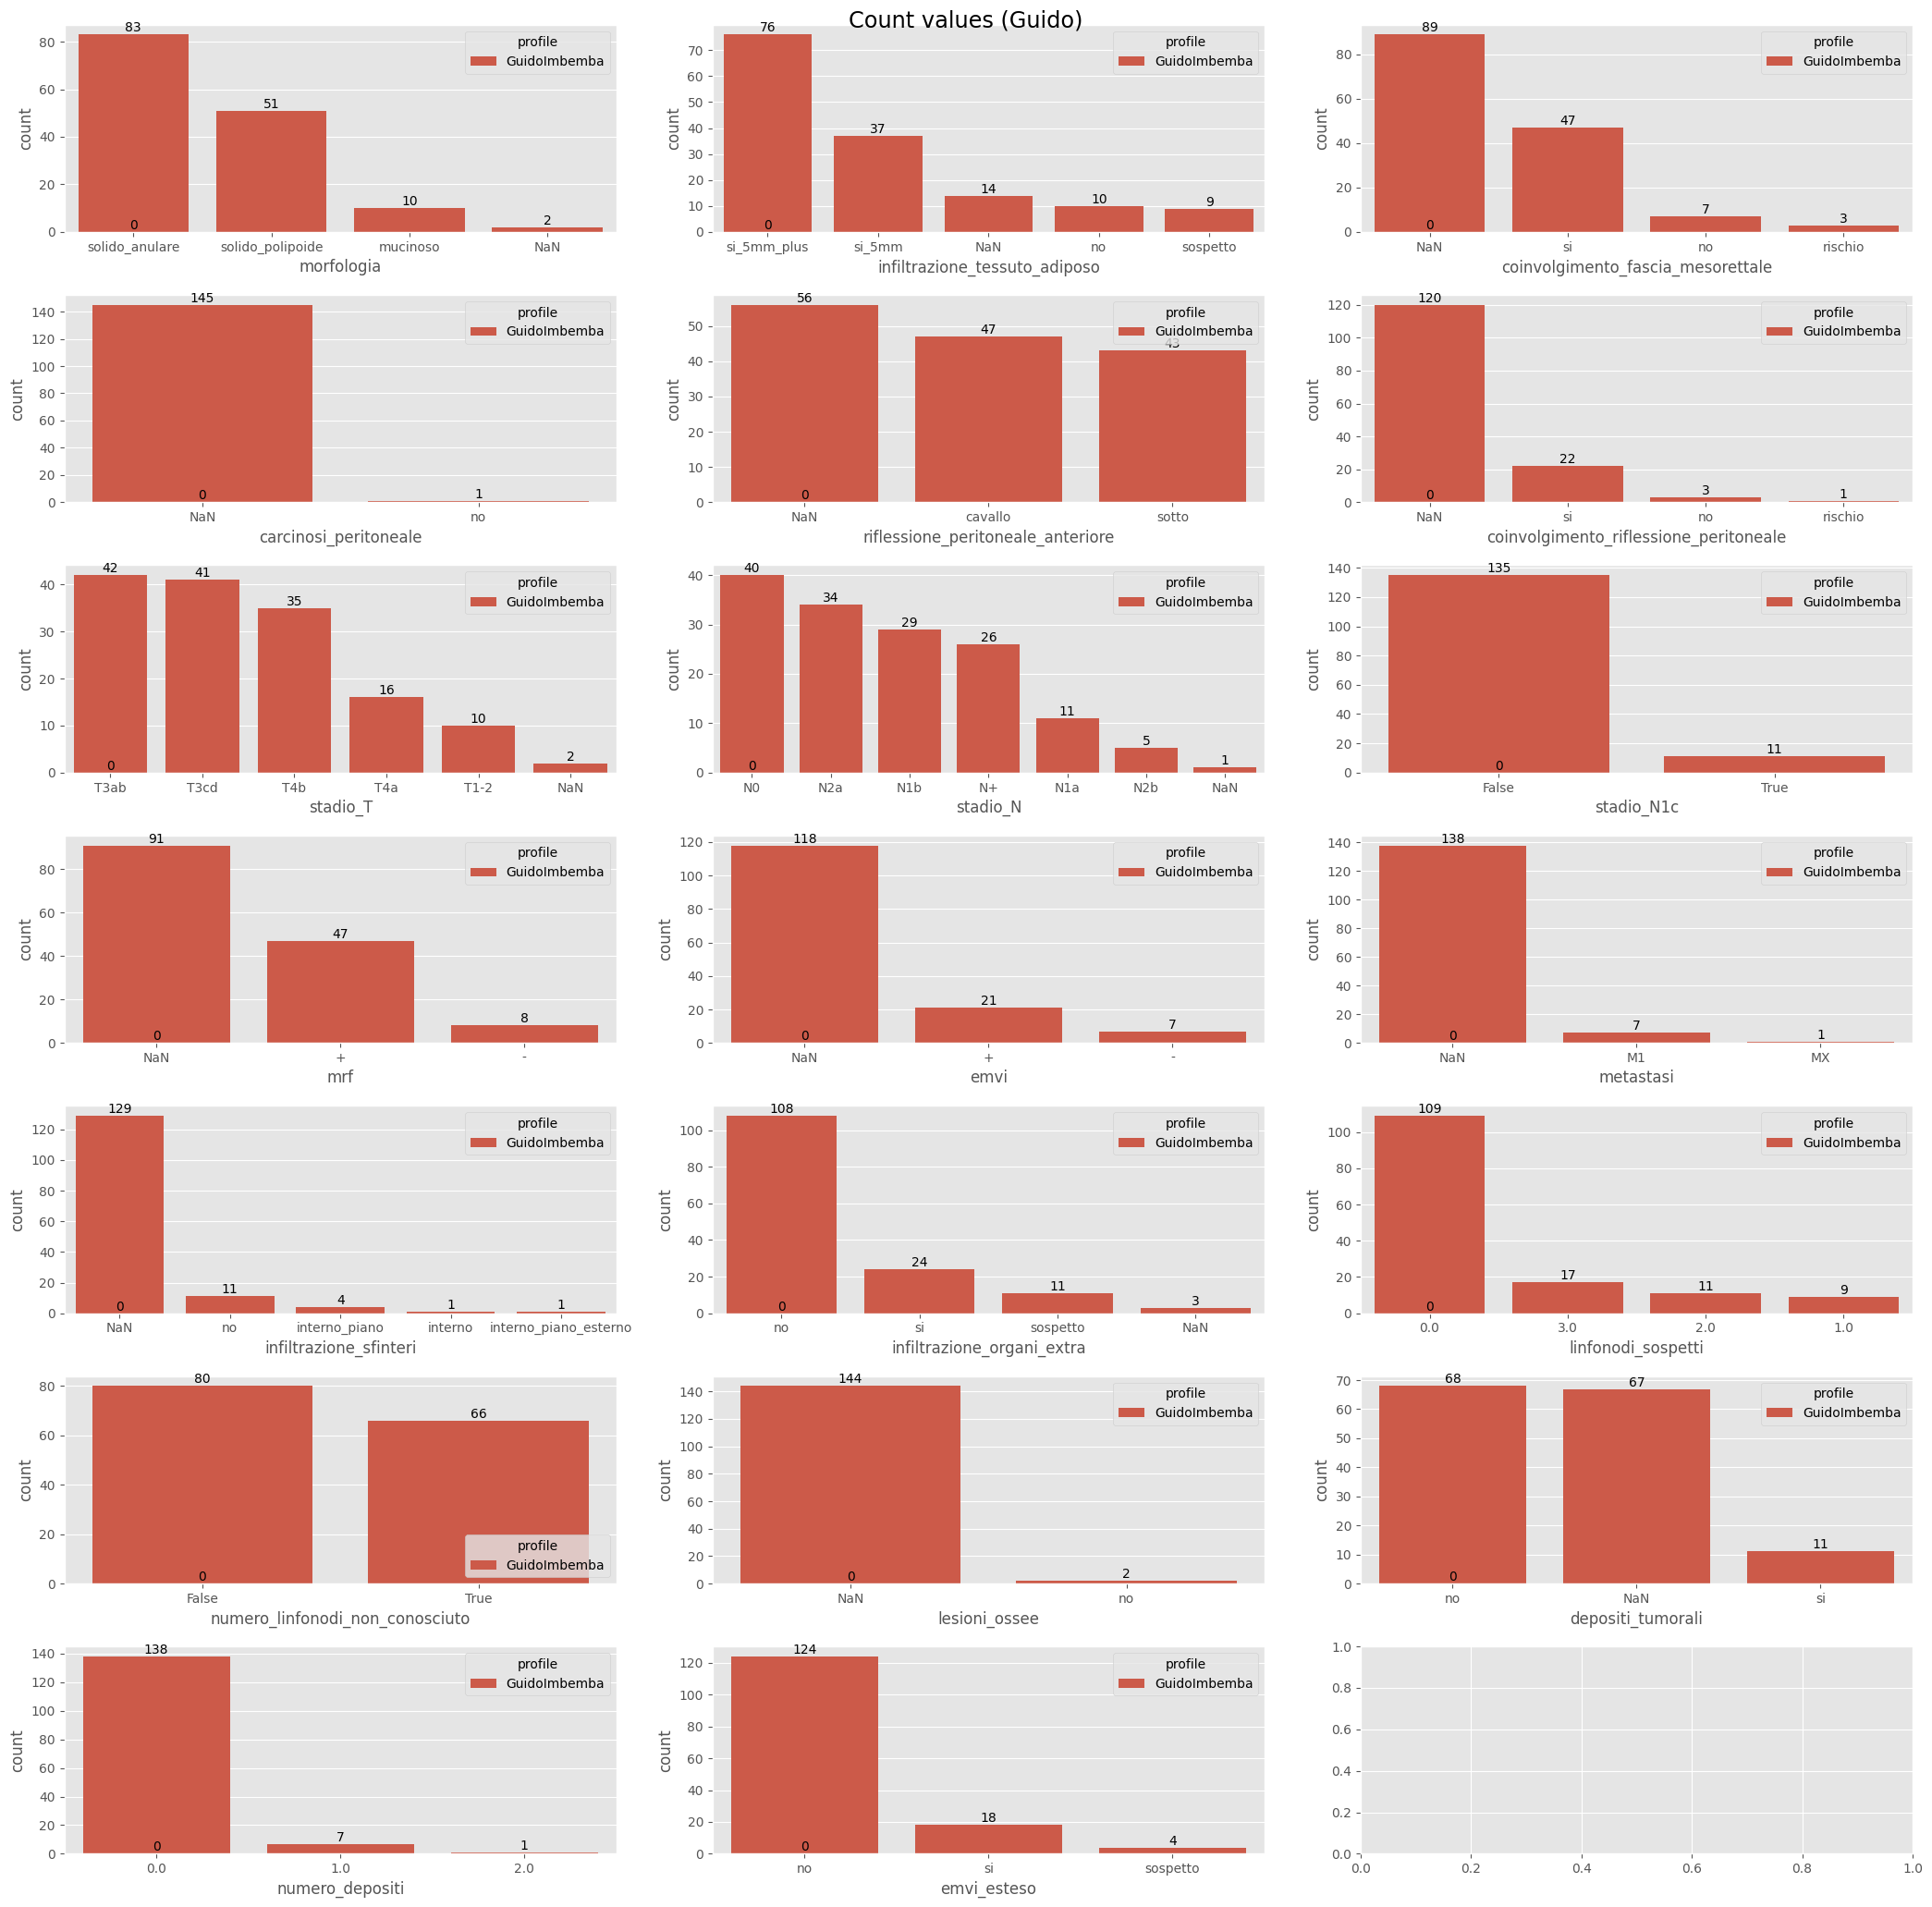

In [270]:
columns_plot = ['morfologia', 'infiltrazione_tessuto_adiposo', 'coinvolgimento_fascia_mesorettale',
                'carcinosi_peritoneale', 'riflessione_peritoneale_anteriore', 'coinvolgimento_riflessione_peritoneale',
                'stadio_T', 'stadio_N', 'stadio_N1c',
                'mrf', 'emvi', 'metastasi',
                'infiltrazione_sfinteri', 'infiltrazione_organi_extra',
                'linfonodi_sospetti', 'numero_linfonodi_non_conosciuto', 'lesioni_ossee',
                'depositi_tumorali', 'numero_depositi', 'emvi_esteso']

#hue_column = None
#columns_plot = [hue_column] + columns_plot

n_columns = 3
n_rows, r = divmod(len(columns_plot), n_columns)
if r != 0:
    n_rows += 1
    
fig, axes = plt.subplots(n_rows, n_columns, figsize=(n_columns*7, n_rows*3))
fig.suptitle("Count values (Guido)", fontsize='xx-large')

for i, col in enumerate(columns_plot):
    ax=axes[i//n_columns][i%n_columns]
    sns.countplot(data=data_plot, x=col, order=data_plot[col].value_counts().index, ax=ax, hue=hue_column)
    # Add values on top of bars
    for p in ax.patches:
        y_text = int(p.get_height())
        x_text = p.get_x() + p.get_width() / 2
        ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')

plt.tight_layout()
#plt.savefig("distribuzione_featurse_per_annotatore.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()

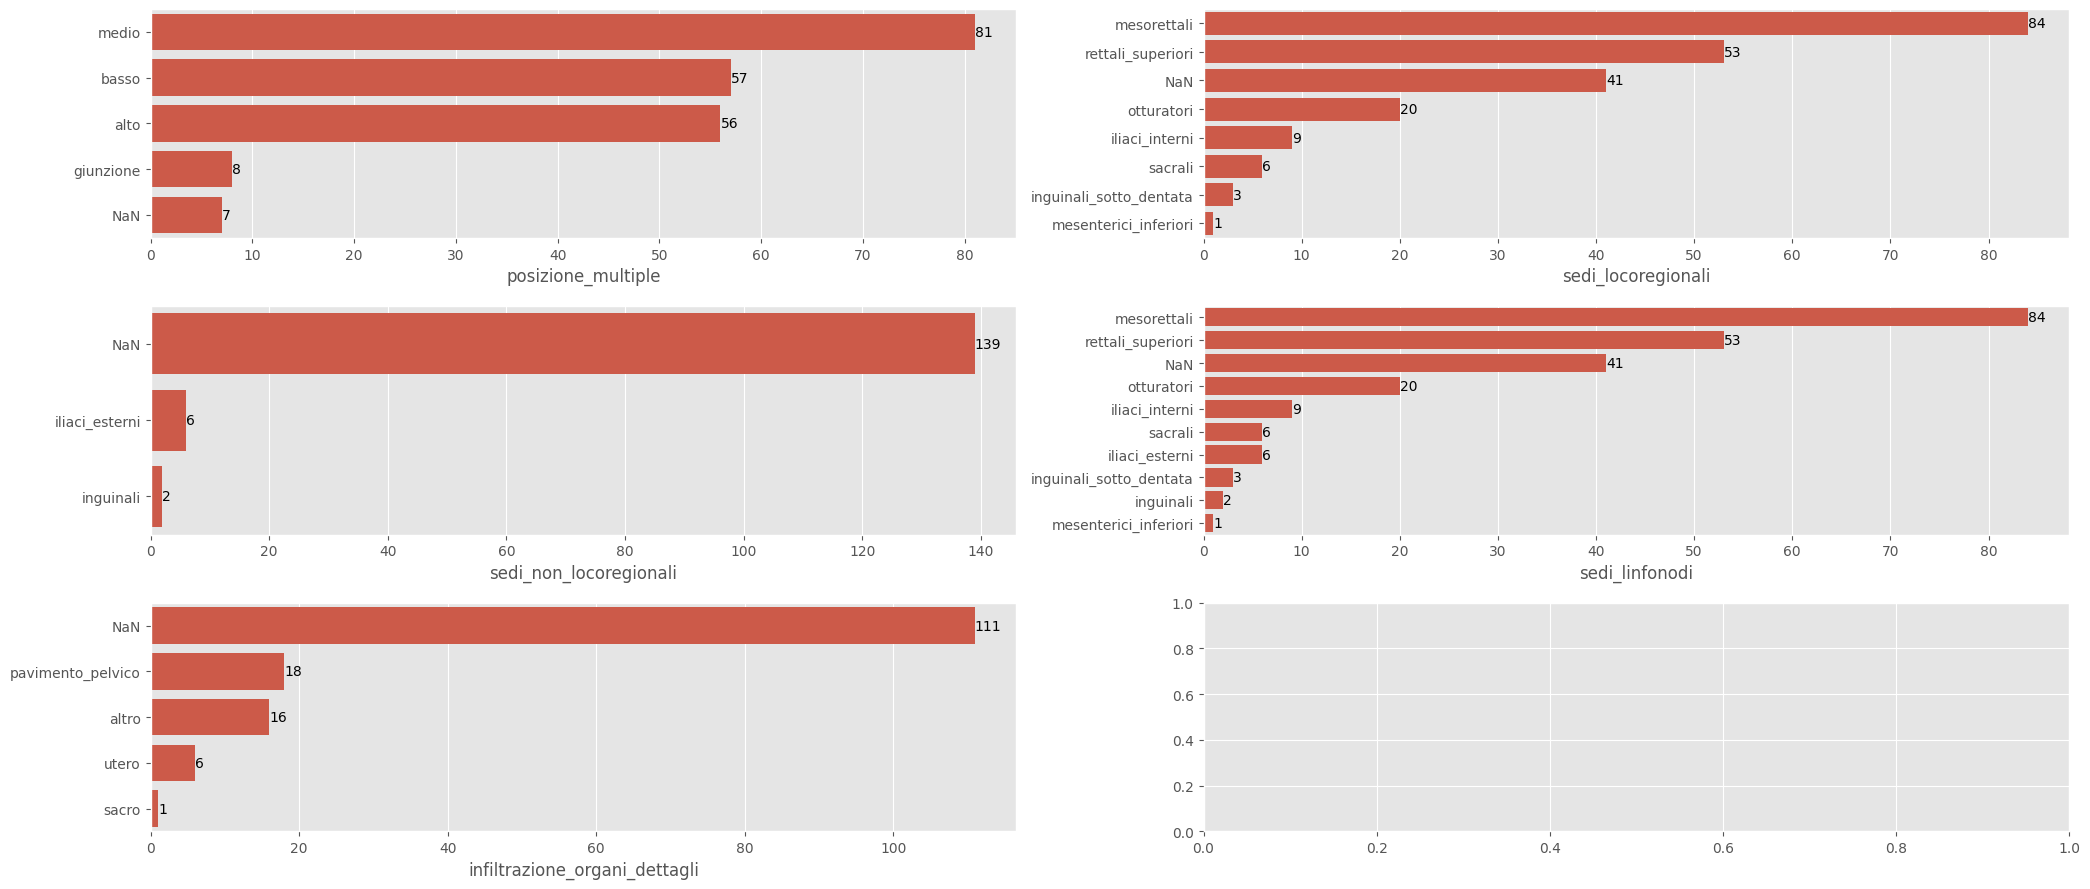

In [271]:
# Analisi posizione, sedi locoregionali, sedi non locoregionali
columns = ['posizione_multiple', 'sedi_locoregionali', 'sedi_non_locoregionali', 'sedi_linfonodi']

possible_values = {col: ['NaN'] for col in columns}

for col in columns:
    for s in data_plot[col].value_counts().index:
        possible_values[col] += ast.literal_eval(s)
    possible_values[col] = list(set(possible_values[col]))    


counts = {
    col: {val: 0 for val in possible_values[col]}
    for col in columns
}
for col in columns:
    for s in data_plot[col]:
        value_list = ast.literal_eval(s)
        for value in possible_values[col]:
            if value in value_list:
                counts[col][value] += 1
        if value_list == []:
            counts[col]['NaN'] += 1
            
            
# Dettagli organi
dettagli_organi = {'NaN'}
altri_organi = set()
for s in data_clean_guido.infiltrazione_organi_dettagli.fillna('NaN').value_counts().index:
    if s != 'NaN' and s != 'nan':
        d = ast.literal_eval(s)
        #print('---')
        dettagli_organi.update(d.keys())
        if 'altro' in d:
            altri_organi.add(d['altro'])
            
dettagli_organi_counts = {val: 0 for val in dettagli_organi}
for s in data_clean_guido.infiltrazione_organi_dettagli.fillna('NaN'):
    if s == 'NaN' or s == 'nan':
        dettagli_organi_counts['NaN'] += 1
    else:
        d = ast.literal_eval(s)
        for key in dettagli_organi:
            if key in d:
                dettagli_organi_counts[key] += 1

counts['infiltrazione_organi_dettagli'] = dettagli_organi_counts
columns.append('infiltrazione_organi_dettagli')
         
         
n_columns = 2
n_rows, r = divmod(len(columns), n_columns)
if r != 0:
    n_rows += 1
            
fig, axes = plt.subplots(n_rows, n_columns, figsize=(21, n_rows*3))
orientation = 'h'
for i, col in enumerate(columns):
    ax=axes[i//n_columns][i%n_columns]
    series = pd.Series(counts[col], name=col).sort_values(ascending=False)
    sns.barplot(data=series, ax=ax, orient=orientation)
    # Add values on top of bars
    if orientation == 'v':
        for p in ax.patches:
            y_text = int(p.get_height())
            x_text = p.get_x() + p.get_width() / 2
            ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')
    if orientation == 'h':
        for p in ax.patches:
            x_text = p.get_width()
            y_text = p.get_y() + p.get_height() / 2
            ax.text(x=x_text, y=y_text, s=f'{int(x_text)}', va='center', ha='left')

plt.tight_layout()
plt.show()

Idea: uniamo sedi locoregionali e non locoregionali e manteniamo solo alcune classi: mesorettali, rettali_superiori, NaN, otturatori, iliaci. I restanti li metteremo in "altro".

Per quanto riguarda i dettagli dell'infiltrazione organi, teniamo solo le classi NaN, pavimento_pelvico, altro.

# Aggregazione / modifica delle colonne

In [288]:
palette_corrente = plt.rcParams['axes.prop_cycle'].by_key()['color']
print(palette_corrente)
display(sns.color_palette(palette_corrente))
new_color = palette_corrente[-2]

['#E24A33', '#348ABD', '#988ED5', '#777777', '#FBC15E', '#8EBA42', '#FFB5B8']


[(0.8862745098039215, 0.2901960784313726, 0.2),
 (0.20392156862745098, 0.5411764705882353, 0.7411764705882353),
 (0.596078431372549, 0.5568627450980392, 0.8352941176470589),
 (0.4666666666666667, 0.4666666666666667, 0.4666666666666667),
 (0.984313725490196, 0.7568627450980392, 0.3686274509803922),
 (0.5568627450980392, 0.7294117647058823, 0.25882352941176473),
 (1.0, 0.7098039215686275, 0.7215686274509804)]

In [282]:
# Dettagli infiltrazione organi
infiltrazione_organi_dettagli_new = []
for s in data_clean_guido.infiltrazione_organi_dettagli.fillna('NaN'):
    dettagli = []
    if s == 'NaN':
        infiltrazione_organi_dettagli_new.append(str(dettagli))
    else:
        d = ast.literal_eval(s)
        if 'pavimento_pelvico' in d:
            dettagli.append('pavimento_pelvico')
        if ('altro' in d) or ('utero' in d) or ('sacro' in d):
            dettagli.append('altro')
        infiltrazione_organi_dettagli_new.append(str(dettagli))
data_clean_guido.loc[:, 'infiltrazione_organi_dettagli'] = infiltrazione_organi_dettagli_new

#print(data_clean_guido.infiltrazione_organi_dettagli.value_counts())

# Sedi linfonodi
sedi_linfonodi_new = []
for s in data_clean_guido.sedi_linfonodi:
    sedi = ast.literal_eval(s)
    sedi_new = set()
    for sede in sedi:
        if sede in ['mesorettali', 'rettali_superiori', 'otturatori']:
            sedi_new.add(sede)
        elif sede in ['iliaci_comuni', 'iliaci_interni', 'iliaci_esterni']:
            sedi_new.add('iliaci')
        else:
            sedi_new.add('altro')
    sedi_linfonodi_new.append(str(list(sedi_new)))
data_clean_guido.loc[:, 'sedi_linfonodi'] = sedi_linfonodi_new
#print(data_clean_guido.sedi_linfonodi.value_counts())

# Coinvolgimento fascia mesorettale. Trasformiamo rischio in si
data_clean_guido.loc[data_clean_guido['coinvolgimento_fascia_mesorettale'] == 'rischio', 'coinvolgimento_fascia_mesorettale'] = 'si'
#print(data_clean_guido.coinvolgimento_fascia_mesorettale.value_counts())

# Coinvolgimento riflessione peritoneale. Trasformiamo rischio in si
data_clean_guido.loc[data_clean_guido['coinvolgimento_riflessione_peritoneale'] == 'rischio', 'coinvolgimento_riflessione_peritoneale'] = 'si'
#print(data_clean_guido.coinvolgimento_riflessione_peritoneale.value_counts())

# Infiltrazione sfinteri. Trasformiamo la posizione in si. per otenere una classe (si/no/NaN)
data_clean_guido.loc[data_clean_guido['infiltrazione_sfinteri'] == 'interno_piano', 'infiltrazione_sfinteri'] = 'si'
data_clean_guido.loc[data_clean_guido['infiltrazione_sfinteri'] == 'interno', 'infiltrazione_sfinteri'] = 'si'
data_clean_guido.loc[data_clean_guido['infiltrazione_sfinteri'] == 'interno_piano_esterno', 'infiltrazione_sfinteri'] = 'si'
#print(data_clean_guido.infiltrazione_sfinteri.value_counts())

# Coinvolgimento riflessione peritoneale. Trasformiamo rischio in si
data_clean_guido.loc[data_clean_guido['emvi_esteso'] == 'sospetto', 'emvi_esteso'] = 'si'
#print(data_clean_guido.emvi_esteso.value_counts())

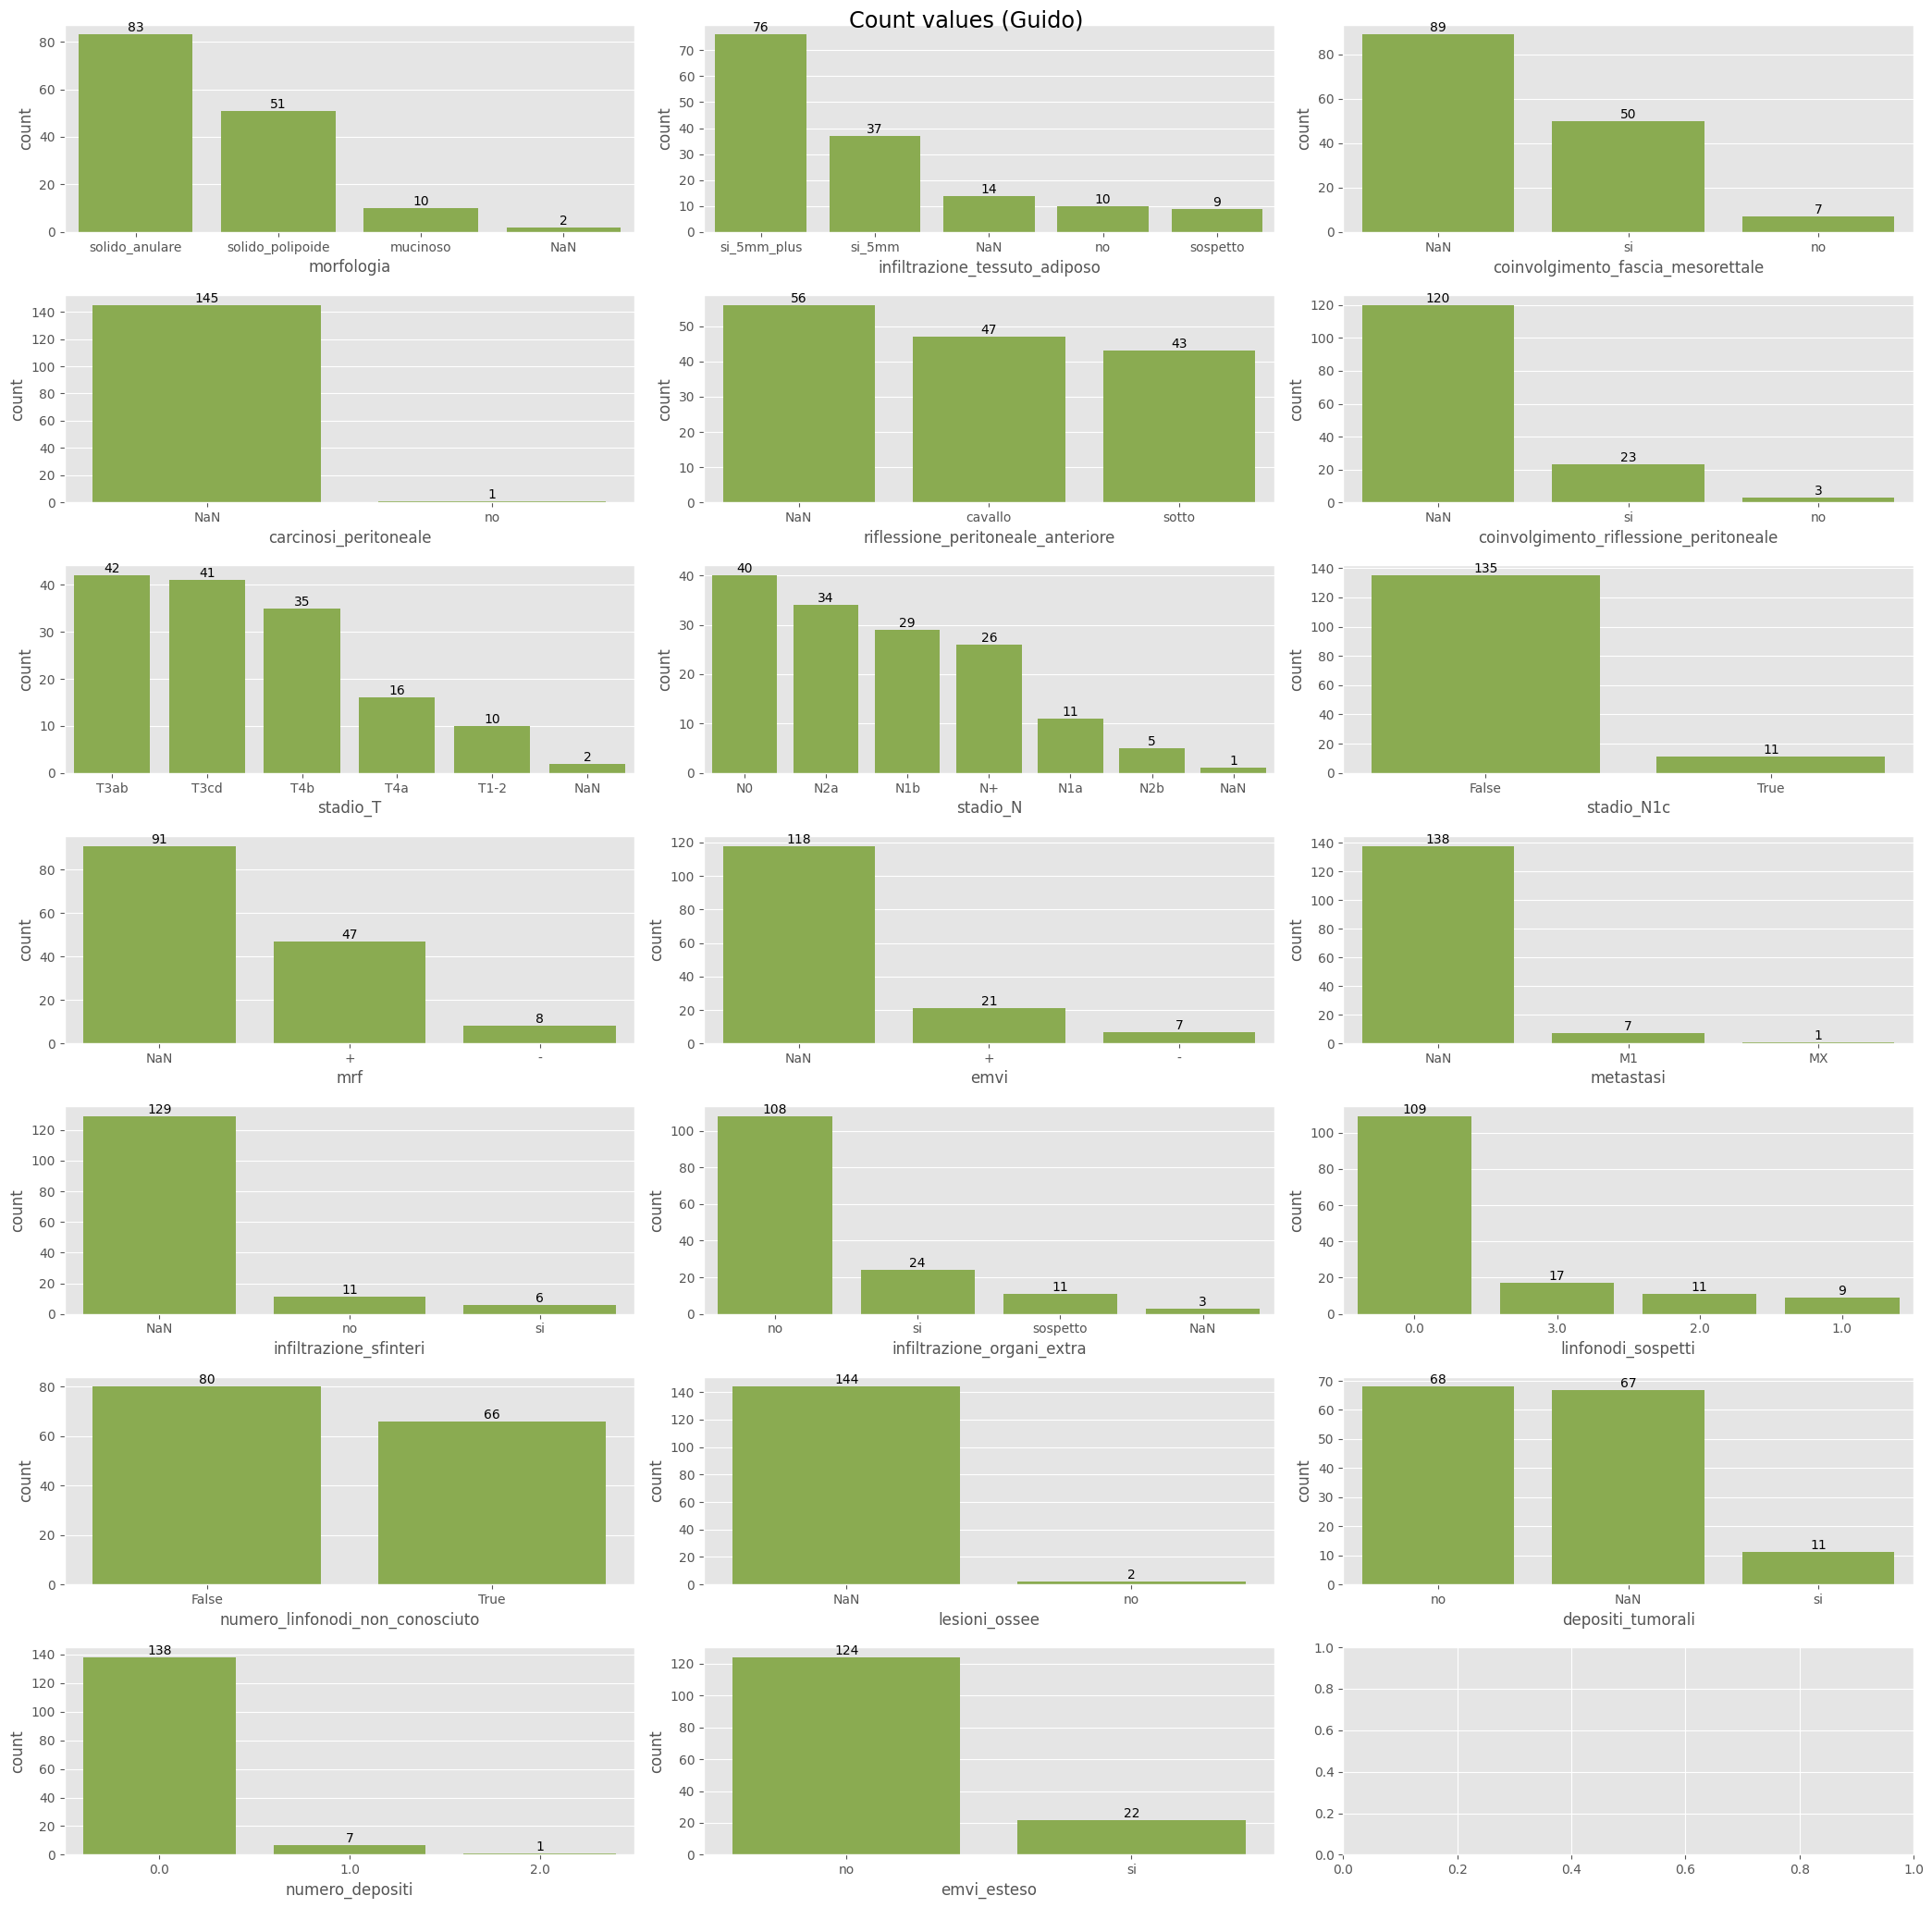

In [290]:
columns_plot = ['morfologia', 'infiltrazione_tessuto_adiposo', 'coinvolgimento_fascia_mesorettale',
                'carcinosi_peritoneale', 'riflessione_peritoneale_anteriore', 'coinvolgimento_riflessione_peritoneale',
                'stadio_T', 'stadio_N', 'stadio_N1c',
                'mrf', 'emvi', 'metastasi',
                'infiltrazione_sfinteri', 'infiltrazione_organi_extra',
                'linfonodi_sospetti', 'numero_linfonodi_non_conosciuto', 'lesioni_ossee',
                'depositi_tumorali', 'numero_depositi', 'emvi_esteso']

#hue_column = None
#columns_plot = [hue_column] + columns_plot

n_columns = 3
n_rows, r = divmod(len(columns_plot), n_columns)
if r != 0:
    n_rows += 1
    
fig, axes = plt.subplots(n_rows, n_columns, figsize=(n_columns*7, n_rows*3))
fig.suptitle("Count values (Guido)", fontsize='xx-large')

for i, col in enumerate(columns_plot):
    ax=axes[i//n_columns][i%n_columns]
    sns.countplot(data=data_plot, x=col, order=data_plot[col].value_counts().index, ax=ax, color=new_color)
    # Add values on top of bars
    for p in ax.patches:
        y_text = int(p.get_height())
        x_text = p.get_x() + p.get_width() / 2
        ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')

plt.tight_layout()
#plt.savefig("distribuzione_featurse_per_annotatore.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()

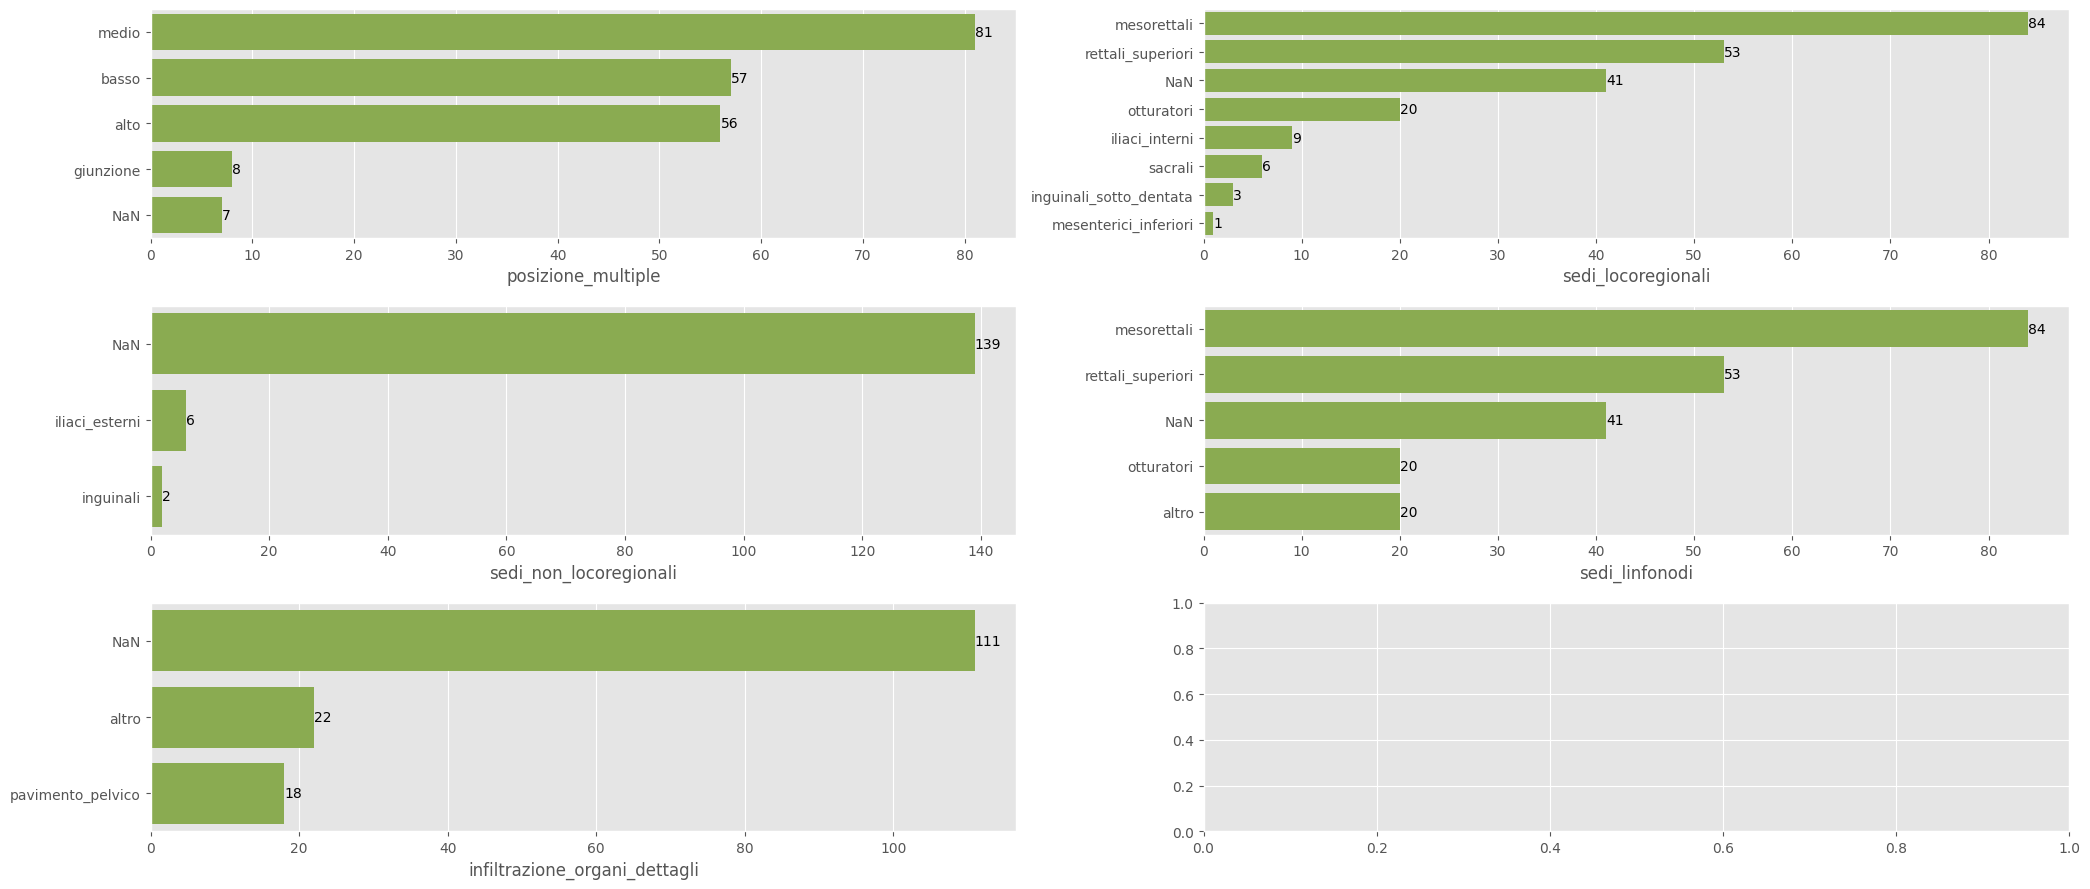

In [291]:
data_plot = data_clean_guido.fillna('NaN')

# Analisi posizione, sedi locoregionali, sedi non locoregionali
columns = ['posizione_multiple', 'sedi_locoregionali', 'sedi_non_locoregionali', 'sedi_linfonodi', 'infiltrazione_organi_dettagli']

possible_values = {col: ['NaN'] for col in columns}

for col in columns:
    for s in data_plot[col].value_counts().index:
        possible_values[col] += ast.literal_eval(s)
    possible_values[col] = list(set(possible_values[col]))    


counts = {
    col: {val: 0 for val in possible_values[col]}
    for col in columns
}
for col in columns:
    for s in data_plot[col]:
        value_list = ast.literal_eval(s)
        for value in possible_values[col]:
            if value in value_list:
                counts[col][value] += 1
        if value_list == []:
            counts[col]['NaN'] += 1
            
         
         
n_columns = 2
n_rows, r = divmod(len(columns), n_columns)
if r != 0:
    n_rows += 1
            
fig, axes = plt.subplots(n_rows, n_columns, figsize=(21, n_rows*3))
orientation = 'h'
for i, col in enumerate(columns):
    ax=axes[i//n_columns][i%n_columns]
    series = pd.Series(counts[col], name=col).sort_values(ascending=False)
    sns.barplot(data=series, ax=ax, orient=orientation, color=new_color)
    # Add values on top of bars
    if orientation == 'v':
        for p in ax.patches:
            y_text = int(p.get_height())
            x_text = p.get_x() + p.get_width() / 2
            ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')
    if orientation == 'h':
        for p in ax.patches:
            x_text = p.get_width()
            y_text = p.get_y() + p.get_height() / 2
            ax.text(x=x_text, y=y_text, s=f'{int(x_text)}', va='center', ha='left')

plt.tight_layout()
plt.show()

In [292]:
# !!! atenzionare questa anomalia
data_clean_guido[(data_clean_guido['linfonodi_sospetti'] == 0) * (data_clean_guido['numero_linfonodi_non_conosciuto'] == False)][['numero_linfonodi_non_conosciuto', 'linfonodi_sospetti', 'sedi_linfonodi']]

,numero_linfonodi_non_conosciuto,linfonodi_sospetti,sedi_linfonodi
3,False,0.0,[]
5,False,0.0,"['otturatori', 'altro']"
8,False,0.0,[]
9,False,0.0,[]
10,False,0.0,[]
14,False,0.0,[]
16,False,0.0,[]
17,False,0.0,[]
19,False,0.0,[]
21,False,0.0,[]


## Colonne target numeriche

In [31]:
colonne_target_numeriche = ['ore_inizio', 'ore_fine', 'dimensione_dll',
    'dimensione_dap', 'spessore_parietale', 'estensione_cranio_caudale',
    'distanza_oai', 'distanza_minima_fascia_ore',
    'linfonodi_sospetti', 'sedi_locoregionali', 'sedi_non_locoregionali',
    'depositi_tumorali', 'numero_depositi']

In [32]:
data_clean_guido[colonne_target_numeriche].describe().T

,count,mean,std,min,25%,50%,75%,max
ore_inizio,58.0,9.310345,3.535320,1.0,6.00,12.0,12.00,12.0
ore_fine,58.0,10.224138,3.469380,1.0,11.25,12.0,12.00,12.0
dimensione_dll,12.0,42.250000,26.330504,15.0,21.50,40.0,49.75,105.0
dimensione_dap,9.0,53.111111,32.643699,25.0,31.00,38.0,53.00,120.0
spessore_parietale,27.0,20.259259,12.522572,7.0,13.00,18.0,21.50,60.0
estensione_cranio_caudale,137.0,48.664234,17.367684,18.0,36.00,47.0,55.00,130.0
distanza_oai,134.0,45.291045,29.472767,0.0,25.00,48.5,65.00,120.0
distanza_minima_fascia_ore,7.0,6.000000,4.760952,1.0,2.00,5.0,10.00,12.0
linfonodi_sospetti,146.0,0.561644,1.050272,0.0,0.00,0.0,0.75,3.0
numero_depositi,146.0,0.061644,0.268395,0.0,0.00,0.0,0.00,2.0


escludere le segenti colonne perchè hanno troppi valori nulli:
- ore_inizio
- ore_fine
- dimensione_dll
- dimensione_dap
- distanza_minima_fascia_ore

## Colonne conclusioni

In [13]:
for col in ['stadio_T', 'stadio_N', 'stadio_N1c', 'mrf', 'emvi', 'metastasi']:
    print(data_clean.fillna('Nan')[col].value_counts())
    print("\n")

stadio_T
T3cd    64
T3ab    63
T4b     49
T4a     28
T1-2    10
Nan      6
Name: count, dtype: int64


stadio_N
N2a    69
N0     45
N+     44
N1b    41
N1a    12
N2b     7
Nan     1
N1c     1
Name: count, dtype: int64


stadio_N1c
False    198
True      22
Name: count, dtype: int64


mrf
Nan    101
+       81
-       38
Name: count, dtype: int64


emvi
Nan    149
+       39
-       32
Name: count, dtype: int64


metastasi
Nan    193
M1      20
MX       7
Name: count, dtype: int64


